===== MAPEO LOGÍSTICO =====
Media     = 0.50148
Varianza  = 0.12463
Asimetría = -0.00099

===== MAPEO TIENDA =====
Media     = 0.50016
Varianza  = 0.08328
Asimetría = 0.00332


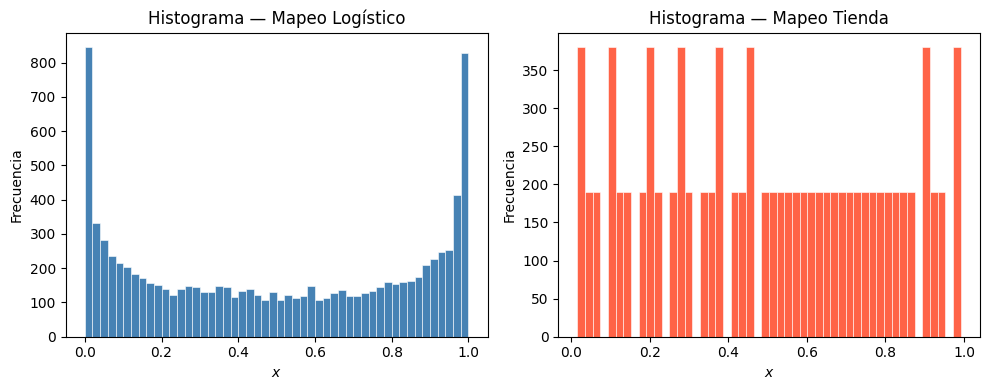

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
from decimal import Decimal, getcontext

# Precisión arbitraria para el mapeo tienda (evita colapso numérico en float64)
getcontext().prec = 50


# 1. Mapeo logístico
def logistic_map(x0, r, N):
    x = np.zeros(N)
    x[0] = x0
    for i in range(1, N):
        x[i] = r * x[i-1] * (1 - x[i-1])
    return x


# 2. Mapeo tienda con precisión arbitraria
#    Nota: el mapeo tienda estándar colapsa a 0 en aritmética float64 tras ~52
#    iteraciones porque multiplica por 2 repetidamente, agotando los bits de
#    mantisa. Se usa el módulo `decimal` para evitar este problema.
def tent_map(x0_str, N):
    x = Decimal(x0_str)
    result = []
    for _ in range(N):
        result.append(float(x))
        if x < Decimal('0.5'):
            x = 2 * x
        else:
            x = 2 * (1 - x)
    return np.array(result)


# 3. Generación de datos
N = 10000
x0 = 0.347   # condición inicial
r = 4        # parámetro caótico del mapa logístico

logistic = logistic_map(x0, r, N)
tent     = tent_map('0.347', N)   # se pasa como string para precisión exacta


# 4. Eliminar transitorio
logistic = logistic[500:]
tent     = tent[500:]


# 5. Estadística
print("===== MAPEO LOGÍSTICO =====")
print("Media     =", round(np.mean(logistic), 5))
print("Varianza  =", round(np.var(logistic),  5))
print("Asimetría =", round(skew(logistic),    5))

print("\n===== MAPEO TIENDA =====")
print("Media     =", round(np.mean(tent), 5))
print("Varianza  =", round(np.var(tent),  5))
print("Asimetría =", round(skew(tent),    5))


# 6. Histogramas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(logistic, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title("Histograma — Mapeo Logístico")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(tent, bins=50, color='tomato', edgecolor='white', linewidth=0.4)
axes[1].set_title("Histograma — Mapeo Tienda")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("histograma.png", dpi=150, bbox_inches='tight')
plt.show()